In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
# Set dataset path
DATASET_PATH = "/content/dataset.csv"

In [ ]:
df = pd.read_csv(DATASET_PATH)

,text,label
0,Why did I only receive a partial amount of wha...,3
1,my atm transaction was wrong,3
2,why did i only get 20.00,3
3,Why is my cash request and the amount I receiv...,3
4,"I tried to withdraw $100, all it gave me was $20.",3
...,...,...
2164,Was charged an ATM fee despite it being a smal...,4
2165,I had a wrong fee charged at this ATM.,4
2166,"When I got cash, I'm pretty sure there was a g...",4
2167,"My account got charged for taking out cash, wh...",4


In [ ]:
labels = sorted(df['label'].unique())
label_map = {old: new for new, old in enumerate(labels)}

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)]

In [ ]:
label_counts = df["label"].value_counts().sort_index().reset_index()
label_counts.columns = ["label", "count"]
print(label_counts)

   label  count
0      0    227
1      1    222
2      2    221
3      3    220
4      4    217
5      5    215
6      6    213
7      7    212
8      8    211
9      9    211


In [ ]:
# Set random seed for reproduceability
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
# Create custom dataset class for Pytorch
class QueryDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
# Split data into Train, Validation test
# First split: Train+Val (85%) and Test (15%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=SEED,
    stratify=df['label']
)

# Second split: Train (70% of total) and Val (15% of total)
# 0.176 of 85% is approximately 15% of the whole dataset
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,
    random_state=SEED,
    stratify=train_val_df['label']
)

In [ ]:
# Tokenization
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [ ]:
# Tokenization helper
def tokenize(texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=128)

In [ ]:
# Create PyTorch datasets for all three splitss
train_ds = QueryDataset(tokenize(train_df['text'].tolist()), train_df['label'].tolist())
val_ds = QueryDataset(tokenize(val_df['text'].tolist()), val_df['label'].tolist())
test_ds = QueryDataset(tokenize(test_df['text'].tolist()), test_df['label'].tolist())

In [ ]:
# Loading distilBERT
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(labels))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Define Training Arguments
# Set f1 as the metric and 10 epochs
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Define f1-score and accuracy as metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

In [ ]:
# Initialize trainer for model with early stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [ ]:
# Fine-tune the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.395936,0.950769,0.950874
2,No log,0.415303,0.947692,0.947817
3,No log,0.356327,0.947692,0.947808
4,No log,0.404055,0.947692,0.947848


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=380, training_loss=0.005950143462733219, metrics={'train_runtime': 32.295, 'train_samples_per_second': 470.042, 'train_steps_per_second': 29.416, 'total_flos': 153978059188800.0, 'train_loss': 0.005950143462733219, 'epoch': 4.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.3952547609806061,
 'eval_accuracy': 0.9507692307692308,
 'eval_f1': 0.9508742953562648,
 'eval_runtime': 0.2948,
 'eval_samples_per_second': 1102.321,
 'eval_steps_per_second': 37.309,
 'epoch': 4.0}

In [ ]:
# Final Evaluation on the Unseen Test Set
print("\n" + "="*30)
print("FINAL TEST SET EVALUATION")
print("="*30)
predictions = trainer.predict(test_ds)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

reverse_map = {v: k for k, v in label_map.items()}
target_names = [f"Class {reverse_map[i]}" for i in range(len(labels))]

print(classification_report(y_true, y_pred, target_names=target_names))

# Save the best model
model.save_pretrained('./final_intent_model')
tokenizer.save_pretrained('./final_intent_model')
print("Model saved to './final_intent_model'")


FINAL TEST SET EVALUATION


              precision    recall  f1-score   support

     Class 0       0.91      0.91      0.91        34
     Class 1       0.89      0.94      0.91        33
     Class 2       0.94      0.97      0.96        33
     Class 3       0.97      0.88      0.92        33
     Class 4       0.87      1.00      0.93        33
     Class 5       1.00      0.94      0.97        32
     Class 6       0.94      0.97      0.95        32
     Class 7       1.00      0.84      0.92        32
     Class 8       0.86      0.97      0.91        32
     Class 9       1.00      0.91      0.95        32

    accuracy                           0.93       326
   macro avg       0.94      0.93      0.93       326
weighted avg       0.94      0.93      0.93       326



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './final_intent_model'


In [ ]:
# Plot confusion matrix between actual and predicted labels
def plot_confusion_matrix(y_true, y_pred, label_map):
    # Create the matrix
    cm = confusion_matrix(y_true, y_pred)

    # Names of the classes in the correct order
    reverse_map = {v: k for k, v in label_map.items()}
    class_names = [f"Class {reverse_map[i]}" for i in range(len(label_map))]

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('Confusion Matrix: Multi Classification')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the plot
    plt.savefig('confusion_matrix.png')

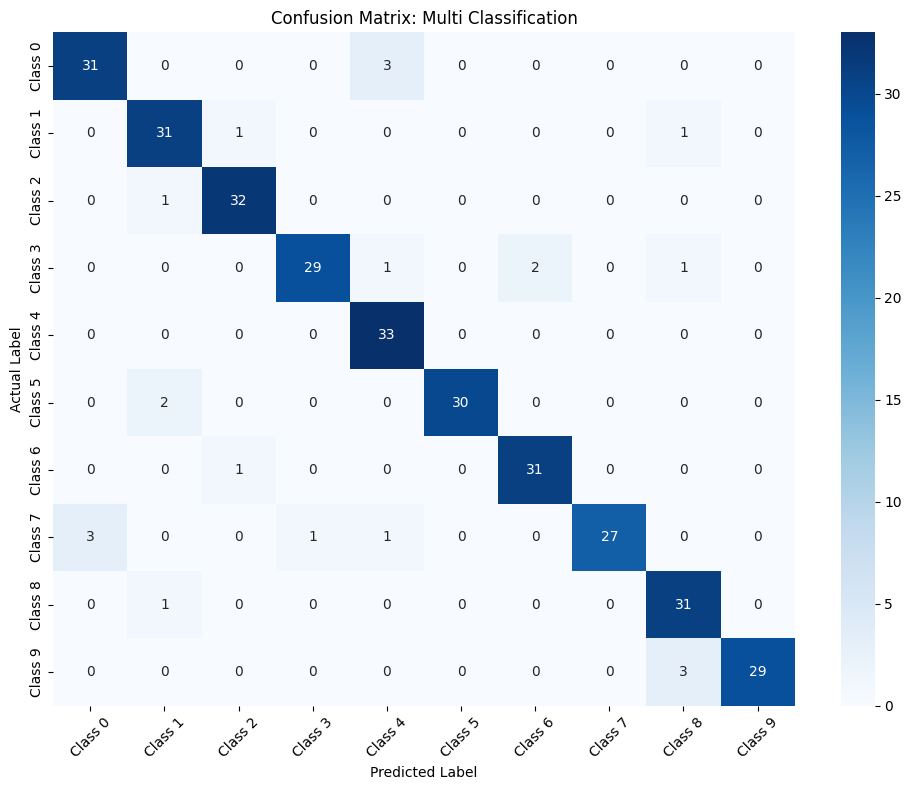

In [ ]:
plot_confusion_matrix(y_true, y_pred, label_map)